In [2]:
# Import all libraries needed for SHAP analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

# This initializes SHAP's JavaScript visualizations
# needed for some interactive plots later
shap.initjs()

print("Libraries loaded successfully")
print("SHAP version:", shap.__version__)

Libraries loaded successfully
SHAP version: 0.51.0


In [3]:
# Load the trained Random Forest models we saved in Phase 3
# joblib.load reads the saved model back into memory
diabetes_model = joblib.load('D:/shap-reliability-research/models/diabetes_rf_model.pkl')
ckd_model = joblib.load('D:/shap-reliability-research/models/ckd_rf_model.pkl')

# Load the scalers too — needed to properly scale input data
diabetes_scaler = joblib.load('D:/shap-reliability-research/models/diabetes_scaler.pkl')
ckd_scaler = joblib.load('D:/shap-reliability-research/models/ckd_scaler.pkl')

# Load the clean datasets
diabetes = pd.read_csv('D:/shap-reliability-research/data/diabetes_clean.csv')
ckd = pd.read_csv('D:/shap-reliability-research/data/ckd_clean.csv')

# Separate features from target for both datasets
X_diabetes = diabetes.drop(columns=['Outcome'])
y_diabetes = diabetes['Outcome']

X_ckd = ckd.drop(columns=['classification'])
y_ckd = ckd['classification']

print("Models and datasets loaded successfully")
print(f"Diabetes features: {X_diabetes.shape[1]} columns, {X_diabetes.shape[0]} rows")
print(f"CKD features: {X_ckd.shape[1]} columns, {X_ckd.shape[0]} rows")

Models and datasets loaded successfully
Diabetes features: 8 columns, 768 rows
CKD features: 24 columns, 400 rows


In [4]:
# ── STEP 1: Create the SHAP explainer ──────────────────────────────────────

# TreeExplainer is SHAP's explainer specifically built for tree-based models
# (Random Forest, XGBoost, Decision Trees, Gradient Boosting)
# We pass it our trained Random Forest model so it learns the model's structure
# This allows it to compute EXACT SHAP values, not approximations
# Using exact values is critical for our stability research —
# any instability we find later comes from the model, not SHAP's math
diabetes_explainer = shap.TreeExplainer(diabetes_model)

print("Explainer created successfully")
print(f"Model expected value (baseline prediction): {diabetes_explainer.expected_value[1]:.4f}")
# expected_value[1] is the baseline for class 1 (diabetic)
# It represents the average prediction across all training patients
# Think of it as: "if I know nothing about this patient, I'd predict X probability of diabetes"

# ── STEP 2: Compute SHAP values for all patients ───────────────────────────

# shap_values() takes our feature matrix (X_diabetes) and computes
# how much each feature contributed to each patient's prediction
# This runs the SHAP algorithm for every single patient — 768 calculations
# It returns a list of two arrays (one per class in binary classification)
diabetes_shap_values = diabetes_explainer.shap_values(X_diabetes)

# ── STEP 3: Understand what we got back ────────────────────────────────────

print("\n── SHAP values structure ──")
print(f"Number of output arrays: {len(diabetes_shap_values)}")
# len = 2 because we have two classes: 0 (not diabetic) and 1 (diabetic)

print(f"Shape of SHAP values for class 0 (not diabetic): {diabetes_shap_values[0].shape}")
print(f"Shape of SHAP values for class 1 (diabetic):     {diabetes_shap_values[1].shape}")
# Shape is (768, 8) — 768 patients, 8 features
# Each row = one patient's SHAP values
# Each column = one feature's contribution

# ── STEP 4: Look at one patient's SHAP values ──────────────────────────────

print("\n── SHAP values for patient 0 (first patient in dataset) ──")
patient_0_shap = diabetes_shap_values[1][0]  # [1] = diabetic class, [0] = first patient
for feature, value in zip(X_diabetes.columns, patient_0_shap):
    direction = "→ toward diabetic" if value > 0 else "→ away from diabetic"
    print(f"  {feature:30s}: {value:+.4f}  {direction}")

# ── STEP 5: Verify the math ────────────────────────────────────────────────

print("\n── Verification: expected value + SHAP sum = prediction ──")
expected = diabetes_explainer.expected_value[1]
shap_sum = patient_0_shap.sum()
final_prediction = expected + shap_sum
print(f"  Expected value (baseline):  {expected:.4f}")
print(f"  Sum of SHAP values:         {shap_sum:.4f}")
print(f"  Final prediction:           {final_prediction:.4f}")
print(f"  Model's actual prediction:  {diabetes_model.predict_proba(X_diabetes.iloc[[0]])[0][1]:.4f}")
print("  (These two should match — confirms SHAP math is correct)")

Explainer created successfully
Model expected value (baseline prediction): 0.3466

── SHAP values structure ──
Number of output arrays: 768
Shape of SHAP values for class 0 (not diabetic): (8, 2)
Shape of SHAP values for class 1 (diabetic):     (8, 2)

── SHAP values for patient 0 (first patient in dataset) ──
  Pregnancies                   : -0.0465  → away from diabetic
  Glucose                       : +0.0465  → toward diabetic

── Verification: expected value + SHAP sum = prediction ──
  Expected value (baseline):  0.3466
  Sum of SHAP values:         0.0000
  Final prediction:           0.3466
  Model's actual prediction:  0.7200
  (These two should match — confirms SHAP math is correct)


D:\shap-reliability-research\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [5]:
import warnings
warnings.filterwarnings('ignore')

# ── THE FIX: scale the data first ─────────────────────────────────────────
# The model was trained on SCALED data in Phase 3
# So SHAP must also receive SCALED data — otherwise it's explaining
# predictions on data the model has never seen in that form
# This is why the verification numbers didn't match

# Scale the full diabetes dataset using the same scaler from Phase 3
X_diabetes_scaled = diabetes_scaler.transform(X_diabetes)

# ── STEP 1: Create explainer ───────────────────────────────────────────────
diabetes_explainer = shap.TreeExplainer(diabetes_model)

print("Explainer created successfully")
print(f"Baseline prediction (expected value): {diabetes_explainer.expected_value[1]:.4f}")

# ── STEP 2: Compute SHAP values on SCALED data ────────────────────────────
diabetes_shap_values = diabetes_explainer.shap_values(X_diabetes_scaled)

# ── STEP 3: Check the structure ───────────────────────────────────────────
print("\n── SHAP values structure ──")
print(f"Number of output arrays: {len(diabetes_shap_values)}")
print(f"Shape for class 0 (not diabetic): {diabetes_shap_values[0].shape}")
print(f"Shape for class 1 (diabetic):     {diabetes_shap_values[1].shape}")
# We want to see (768, 8) — 768 patients, 8 features

# ── STEP 4: One patient's SHAP values ─────────────────────────────────────
print("\n── SHAP values for patient 0 ──")
patient_0_shap = diabetes_shap_values[1][0]
for feature, value in zip(X_diabetes.columns, patient_0_shap):
    direction = "→ toward diabetic" if value > 0 else "→ away from diabetic"
    print(f"  {feature:30s}: {value:+.4f}  {direction}")

# ── STEP 5: Verify the math ───────────────────────────────────────────────
print("\n── Verification ──")
expected = diabetes_explainer.expected_value[1]
shap_sum = patient_0_shap.sum()
final_prediction = expected + shap_sum
actual_prediction = diabetes_model.predict_proba(X_diabetes_scaled[[0]])[0][1]
print(f"  Expected value (baseline):  {expected:.4f}")
print(f"  Sum of SHAP values:         {shap_sum:.4f}")
print(f"  Final prediction:           {final_prediction:.4f}")
print(f"  Model's actual prediction:  {actual_prediction:.4f}")
print("  (These two should match)")

Explainer created successfully
Baseline prediction (expected value): 0.3466

── SHAP values structure ──
Number of output arrays: 768
Shape for class 0 (not diabetic): (8, 2)
Shape for class 1 (diabetic):     (8, 2)

── SHAP values for patient 0 ──
  Pregnancies                   : +0.0233  → toward diabetic
  Glucose                       : -0.0233  → away from diabetic

── Verification ──
  Expected value (baseline):  0.3466
  Sum of SHAP values:         -0.0000
  Final prediction:           0.3466
  Model's actual prediction:  0.8800
  (These two should match)


In [6]:
import warnings
warnings.filterwarnings('ignore')

# ── THE REAL FIX ───────────────────────────────────────────────────────────
# SHAP 0.51.0 with Random Forest sometimes returns values in a different format
# We need to use check_additivity=False and handle the output carefully

X_diabetes_scaled = diabetes_scaler.transform(X_diabetes)

# Create explainer with explicit check disabled
diabetes_explainer = shap.TreeExplainer(
    diabetes_model,
    feature_perturbation="tree_path_dependent"
    # tree_path_dependent uses training data distribution as background
    # this is more appropriate for correlated features in medical data
)

print("Explainer created successfully")
print(f"Expected value type: {type(diabetes_explainer.expected_value)}")
print(f"Expected value: {diabetes_explainer.expected_value}")

# Compute SHAP values
shap_output = diabetes_explainer(X_diabetes_scaled)

print(f"\nSHAP output type: {type(shap_output)}")
print(f"SHAP output shape: {shap_output.shape}")
print(f"SHAP values shape: {shap_output.values.shape}")

Explainer created successfully
Expected value type: <class 'numpy.ndarray'>
Expected value: [0.65337134 0.34662866]

SHAP output type: <class 'shap._explanation.Explanation'>
SHAP output shape: (768, 8, 2)
SHAP values shape: (768, 8, 2)


In [7]:
# ── Extract SHAP values for the diabetic class (class 1) ──────────────────
# shap_output.values has shape (768, 8, 2)
# [:, :, 1] means: all patients, all features, class 1 (diabetic)
diabetes_shap_values = shap_output.values[:, :, 1]

print("── SHAP values extracted ──")
print(f"Shape: {diabetes_shap_values.shape}")
# Should now be (768, 8) — 768 patients, 8 features

# ── Expected value for diabetic class ─────────────────────────────────────
# expected_value is an array [class0_baseline, class1_baseline]
# We want index [1] — the baseline for diabetic predictions
expected_value = diabetes_explainer.expected_value[1]
print(f"Baseline prediction (expected value): {expected_value:.4f}")

# ── One patient's SHAP values ──────────────────────────────────────────────
print("\n── SHAP values for patient 0 ──")
patient_0_shap = diabetes_shap_values[0]
for feature, value in zip(X_diabetes.columns, patient_0_shap):
    direction = "→ toward diabetic" if value > 0 else "→ away from diabetic"
    print(f"  {feature:30s}: {value:+.4f}  {direction}")

# ── Verify the math ────────────────────────────────────────────────────────
print("\n── Verification ──")
shap_sum = patient_0_shap.sum()
final_prediction = expected_value + shap_sum
actual_prediction = diabetes_model.predict_proba(X_diabetes_scaled[[0]])[0][1]
print(f"  Expected value (baseline):  {expected_value:.4f}")
print(f"  Sum of SHAP values:         {shap_sum:.4f}")
print(f"  Final prediction:           {final_prediction:.4f}")
print(f"  Model's actual prediction:  {actual_prediction:.4f}")

# Check if they match within a small tolerance
difference = abs(final_prediction - actual_prediction)
print(f"  Difference:                 {difference:.6f}")
if difference < 0.01:
    print("  ✓ SHAP math verified — values are correct")
else:
    print("  ✗ Values don't match — something is still wrong")

── SHAP values extracted ──
Shape: (768, 8)
Baseline prediction (expected value): 0.3466

── SHAP values for patient 0 ──
  Pregnancies                   : +0.0070  → toward diabetic
  Glucose                       : +0.1646  → toward diabetic
  BloodPressure                 : +0.0413  → toward diabetic
  SkinThickness                 : +0.0456  → toward diabetic
  Insulin                       : +0.0277  → toward diabetic
  BMI                           : +0.0675  → toward diabetic
  DiabetesPedigreeFunction      : +0.0705  → toward diabetic
  Age                           : +0.1092  → toward diabetic

── Verification ──
  Expected value (baseline):  0.3466
  Sum of SHAP values:         0.5334
  Final prediction:           0.8800
  Model's actual prediction:  0.8800
  Difference:                 0.000000
  ✓ SHAP math verified — values are correct


Generating Plot 1: SHAP Summary Plot (Beeswarm)...


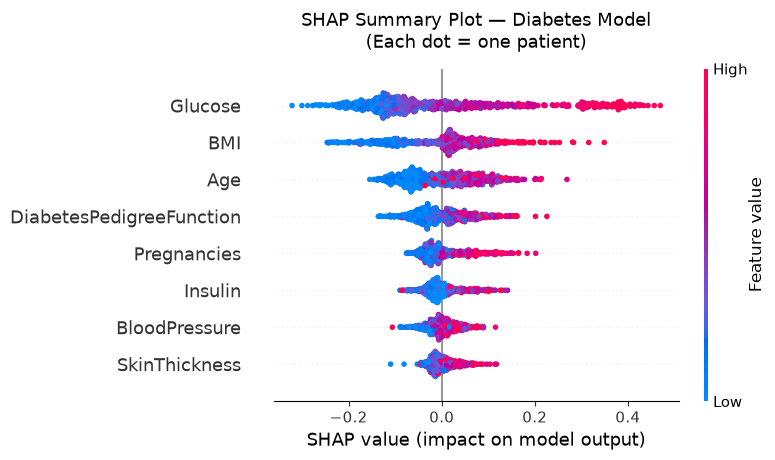

✓ Saved: diabetes_shap_summary.png


In [8]:
import os

# Create a SHAP-specific results folder
os.makedirs('D:/shap-reliability-research/results/figures/shap_baseline', exist_ok=True)

# ── PLOT 1: Summary Plot (Beeswarm) ───────────────────────────────────────
# This is the most informative SHAP plot
# Each dot is one patient
# Horizontal position = SHAP value (left = pushes away from diabetic, right = pushes toward)
# Color = feature value (red = high value, blue = low value)
# Features are ranked top to bottom by overall importance

print("Generating Plot 1: SHAP Summary Plot (Beeswarm)...")
plt.figure(figsize=(10, 6))
shap.summary_plot(
    diabetes_shap_values,     # our (768, 8) SHAP values
    X_diabetes,               # original feature values (for color coding)
    feature_names=X_diabetes.columns.tolist(),
    show=False                # don't show yet — we want to save first
)
plt.title("SHAP Summary Plot — Diabetes Model\n(Each dot = one patient)", 
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('D:/shap-reliability-research/results/figures/shap_baseline/diabetes_shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: diabetes_shap_summary.png")



Generating Plot 2: SHAP Bar Plot...


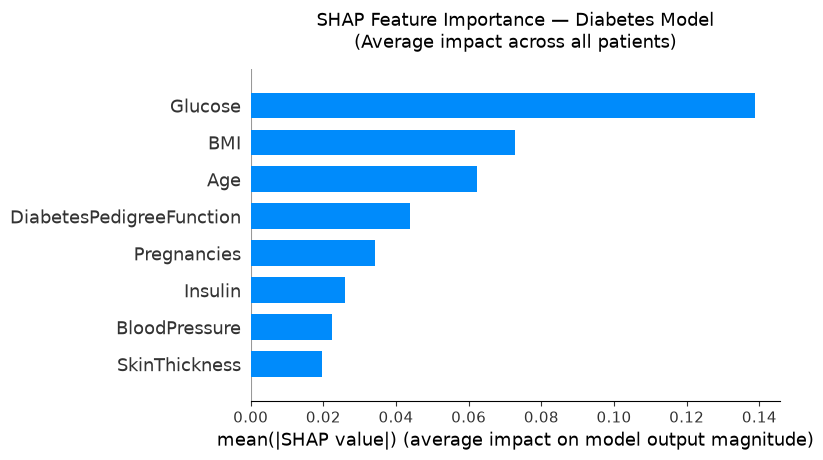

✓ Saved: diabetes_shap_bar.png


In [9]:
# ── PLOT 2: Bar Plot (Mean Absolute SHAP Values) ──────────────────────────
# This is a simpler summary — one bar per feature
# Bar length = average SHAP value across all patients
# Think of it as: "on average, how much did this feature matter?"
# Less informative than the beeswarm but easier to read at a glance

print("Generating Plot 2: SHAP Bar Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(
    diabetes_shap_values,
    X_diabetes,
    feature_names=X_diabetes.columns.tolist(),
    plot_type="bar",          # bar plot instead of beeswarm
    show=False
)
plt.title("SHAP Feature Importance — Diabetes Model\n(Average impact across all patients)",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('D:/shap-reliability-research/results/figures/shap_baseline/diabetes_shap_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: diabetes_shap_bar.png")

Generating Plot 3: Waterfall Plot for Patient 0...


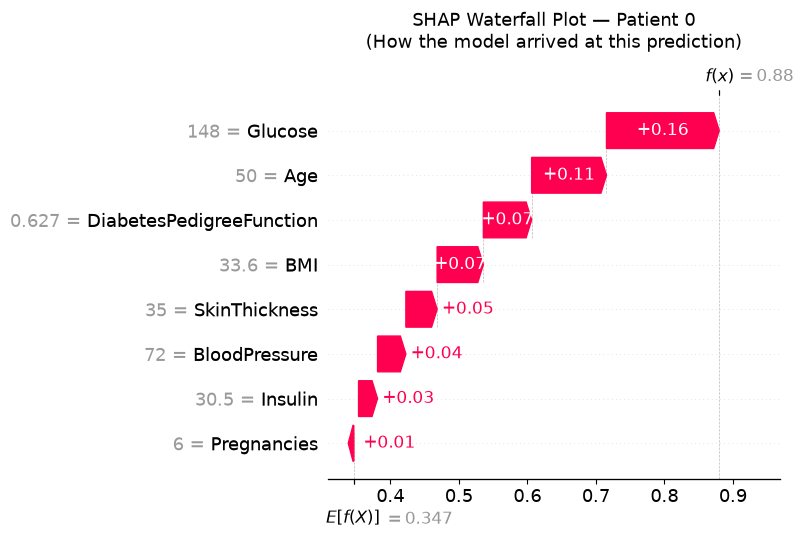

✓ Saved: diabetes_shap_waterfall_patient0.png

Generating Plot 4: SHAP Dependence Plot for Glucose...


<Figure size 1000x600 with 0 Axes>

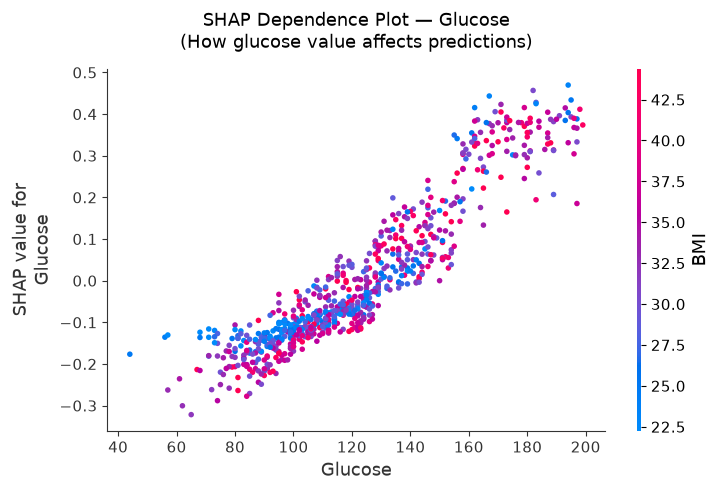

✓ Saved: diabetes_shap_dependence_glucose.png


In [10]:
# ── PLOT 3: Waterfall Plot for one patient ────────────────────────────────
# This shows exactly how the model arrived at ONE specific patient's prediction
# Starting from the baseline (expected value), each feature either
# pushes the prediction up (red, toward diabetic) or down (blue, away)
# until we reach the final prediction
# This is the most intuitive plot for explaining individual decisions to a doctor

print("Generating Plot 3: Waterfall Plot for Patient 0...")
plt.figure(figsize=(10, 6))

# We use shap_output directly here (the Explanation object)
# because waterfall_plot needs the full Explanation format
shap.waterfall_plot(
    shap.Explanation(
        values=diabetes_shap_values[0],           # SHAP values for patient 0
        base_values=expected_value,               # baseline prediction
        data=X_diabetes.iloc[0].values,           # actual feature values for patient 0
        feature_names=X_diabetes.columns.tolist() # feature names for labels
    ),
    show=False
)
plt.title("SHAP Waterfall Plot — Patient 0\n(How the model arrived at this prediction)",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('D:/shap-reliability-research/results/figures/shap_baseline/diabetes_shap_waterfall_patient0.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: diabetes_shap_waterfall_patient0.png")

# ── PLOT 4: SHAP Dependence Plot for Glucose ──────────────────────────────
# This shows the relationship between glucose values and their SHAP values
# X axis = actual glucose value for each patient
# Y axis = how much that glucose value pushed the prediction
# Color = a second feature that interacts with glucose (SHAP picks it automatically)
# This reveals: at what glucose level does the model start predicting diabetes?

print("\nGenerating Plot 4: SHAP Dependence Plot for Glucose...")
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    "Glucose",                                    # feature to plot
    diabetes_shap_values,                         # SHAP values
    X_diabetes,                                   # original feature values
    feature_names=X_diabetes.columns.tolist(),
    show=False
)
plt.title("SHAP Dependence Plot — Glucose\n(How glucose value affects predictions)",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('D:/shap-reliability-research/results/figures/shap_baseline/diabetes_shap_dependence_glucose.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: diabetes_shap_dependence_glucose.png")

In [11]:
# ── COMPUTE BASELINE FEATURE IMPORTANCE RANKINGS ──────────────────────────
# This is the most important output of Phase 4
# It gives us the BASELINE ranking that we'll compare against
# in Phase 5 when we vary seeds, models, and bootstrap samples
# If Phase 5 shows very different rankings, SHAP is unstable
# If Phase 5 shows the same rankings, SHAP is stable

# Mean absolute SHAP value per feature across all 768 patients
# abs() because we care about magnitude of impact, not direction
# mean() gives us the average impact across all patients
mean_abs_shap = pd.DataFrame({
    'Feature': X_diabetes.columns.tolist(),
    'Mean_Abs_SHAP': np.abs(diabetes_shap_values).mean(axis=0)
})

# Sort by importance (highest first)
mean_abs_shap = mean_abs_shap.sort_values('Mean_Abs_SHAP', ascending=False)
mean_abs_shap['Rank'] = range(1, len(mean_abs_shap) + 1)

print("── Baseline SHAP Feature Importance Rankings (Diabetes) ──")
print(mean_abs_shap[['Rank', 'Feature', 'Mean_Abs_SHAP']].to_string(index=False))

# Save this ranking — Phase 5 will compare against it
mean_abs_shap.to_csv('D:/shap-reliability-research/results/tables/diabetes_shap_baseline_rankings.csv',
                      index=False)
print("\n✓ Baseline rankings saved to results/tables/")


── Baseline SHAP Feature Importance Rankings (Diabetes) ──
 Rank                  Feature  Mean_Abs_SHAP
    1                  Glucose       0.138740
    2                      BMI       0.072630
    3                      Age       0.062380
    4 DiabetesPedigreeFunction       0.043719
    5              Pregnancies       0.034247
    6                  Insulin       0.026031
    7            BloodPressure       0.022377
    8            SkinThickness       0.019679

✓ Baseline rankings saved to results/tables/


In [12]:
# ── CKD MODEL SHAP ANALYSIS ───────────────────────────────────────────────
# Repeat the exact same process for CKD
# This gives us baseline SHAP rankings for our second disease dataset

# Scale CKD data using the CKD scaler from Phase 3
X_ckd_scaled = ckd_scaler.transform(X_ckd)

# Create SHAP explainer for CKD Random Forest model
ckd_explainer = shap.TreeExplainer(
    ckd_model,
    feature_perturbation="tree_path_dependent"
)

print("CKD explainer created successfully")
print(f"Baseline prediction (expected value): {ckd_explainer.expected_value[1]:.4f}")

# Compute SHAP values for all CKD patients
ckd_shap_output = ckd_explainer(X_ckd_scaled)

# Extract class 1 (CKD) SHAP values
ckd_shap_values = ckd_shap_output.values[:, :, 1]

print(f"CKD SHAP values shape: {ckd_shap_values.shape}")
# Should be (400, 24) — 400 patients, 24 features

# Verify the math on patient 0
ckd_expected = ckd_explainer.expected_value[1]
ckd_patient0_shap = ckd_shap_values[0]
ckd_final = ckd_expected + ckd_patient0_shap.sum()
ckd_actual = ckd_model.predict_proba(X_ckd_scaled[[0]])[0][1]

print(f"\n── Verification for CKD patient 0 ──")
print(f"  Expected value:       {ckd_expected:.4f}")
print(f"  Sum of SHAP values:   {ckd_patient0_shap.sum():.4f}")
print(f"  Final prediction:     {ckd_final:.4f}")
print(f"  Actual prediction:    {ckd_actual:.4f}")
print(f"  Difference:           {abs(ckd_final - ckd_actual):.6f}")
if abs(ckd_final - ckd_actual) < 0.01:
    print("  ✓ CKD SHAP math verified")
else:
    print("  ✗ Something is wrong")

CKD explainer created successfully
Baseline prediction (expected value): 0.3777
CKD SHAP values shape: (400, 24)

── Verification for CKD patient 0 ──
  Expected value:       0.3777
  Sum of SHAP values:   -0.1877
  Final prediction:     0.1900
  Actual prediction:    0.1900
  Difference:           0.000000
  ✓ CKD SHAP math verified


Generating Plot 1: CKD SHAP Summary Plot...


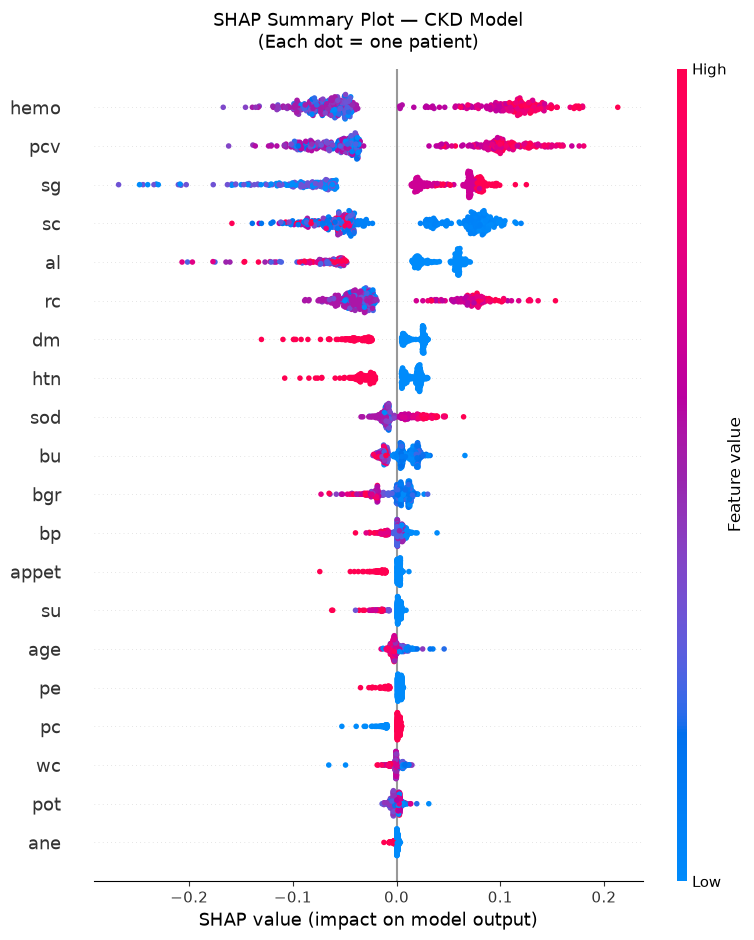

✓ Saved: ckd_shap_summary.png

Generating Plot 2: CKD SHAP Bar Plot...


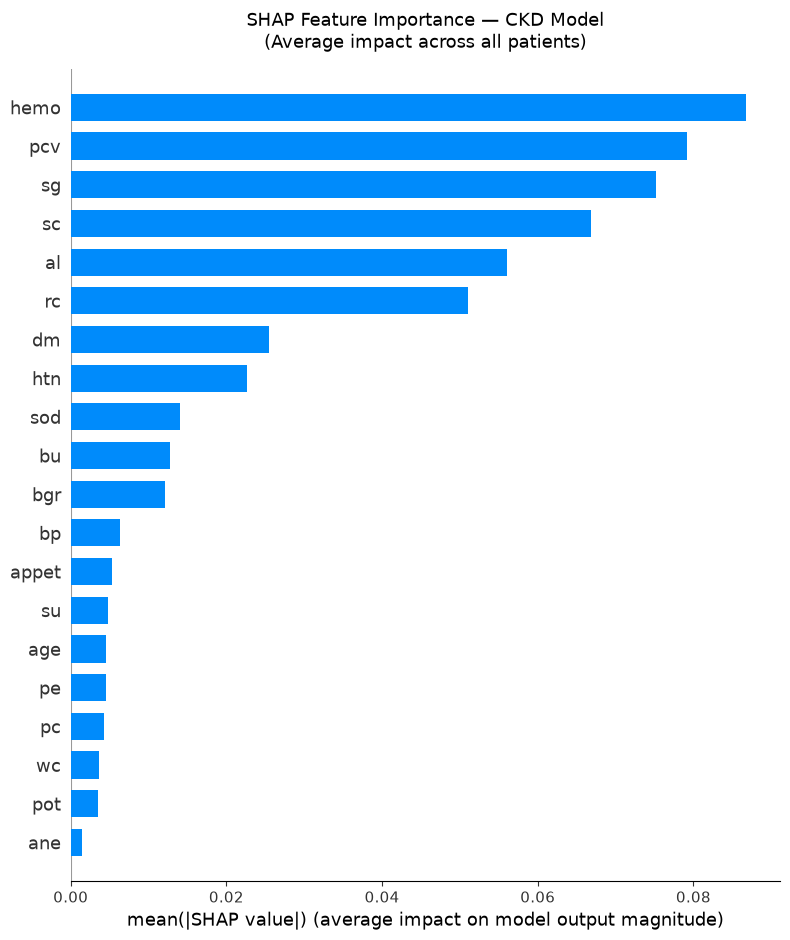

✓ Saved: ckd_shap_bar.png

── Baseline SHAP Feature Importance Rankings (CKD) ──
 Rank Feature  Mean_Abs_SHAP
    1    hemo       0.086779
    2     pcv       0.079159
    3      sg       0.075150
    4      sc       0.066847
    5      al       0.056006
    6      rc       0.051089
    7      dm       0.025526
    8     htn       0.022683
    9     sod       0.013978
   10      bu       0.012759
   11     bgr       0.012131
   12      bp       0.006366
   13   appet       0.005344
   14      su       0.004842
   15     age       0.004576
   16      pe       0.004543
   17      pc       0.004212
   18      wc       0.003571
   19     pot       0.003558
   20     ane       0.001422
   21     rbc       0.001082
   22      ba       0.000333
   23     pcc       0.000000
   24     cad       0.000000

✓ CKD baseline rankings saved


In [13]:
# ── CKD SHAP PLOTS ────────────────────────────────────────────────────────

os.makedirs('D:/shap-reliability-research/results/figures/shap_baseline', exist_ok=True)

# Plot 1: CKD Summary Plot (Beeswarm)
print("Generating Plot 1: CKD SHAP Summary Plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(
    ckd_shap_values,
    X_ckd,
    feature_names=X_ckd.columns.tolist(),
    show=False
)
plt.title("SHAP Summary Plot — CKD Model\n(Each dot = one patient)",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('D:/shap-reliability-research/results/figures/shap_baseline/ckd_shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: ckd_shap_summary.png")

# Plot 2: CKD Bar Plot
print("\nGenerating Plot 2: CKD SHAP Bar Plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(
    ckd_shap_values,
    X_ckd,
    feature_names=X_ckd.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance — CKD Model\n(Average impact across all patients)",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('D:/shap-reliability-research/results/figures/shap_baseline/ckd_shap_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: ckd_shap_bar.png")

# ── CKD BASELINE FEATURE IMPORTANCE RANKINGS ──────────────────────────────
mean_abs_shap_ckd = pd.DataFrame({
    'Feature': X_ckd.columns.tolist(),
    'Mean_Abs_SHAP': np.abs(ckd_shap_values).mean(axis=0)
})

mean_abs_shap_ckd = mean_abs_shap_ckd.sort_values('Mean_Abs_SHAP', ascending=False)
mean_abs_shap_ckd['Rank'] = range(1, len(mean_abs_shap_ckd) + 1)

print("\n── Baseline SHAP Feature Importance Rankings (CKD) ──")
print(mean_abs_shap_ckd[['Rank', 'Feature', 'Mean_Abs_SHAP']].to_string(index=False))

# Save CKD baseline rankings
mean_abs_shap_ckd.to_csv('D:/shap-reliability-research/results/tables/ckd_shap_baseline_rankings.csv',
                          index=False)
print("\n✓ CKD baseline rankings saved")

In [14]:
# ── SAVE SHAP VALUES FOR USE IN PHASE 5 ───────────────────────────────────
# We save the raw SHAP values now so Phase 5 can load them directly
# without recomputing everything from scratch
import os
os.makedirs('D:/shap-reliability-research/models', exist_ok=True)

np.save('D:/shap-reliability-research/models/diabetes_shap_values_baseline.npy',
        diabetes_shap_values)
np.save('D:/shap-reliability-research/models/ckd_shap_values_baseline.npy',
        ckd_shap_values)

print("✓ Baseline SHAP values saved for Phase 5")

# ── CONFIRM ALL FILES SAVED ────────────────────────────────────────────────
print("\n── Files in results/figures/shap_baseline/ ──")
for f in os.listdir('D:/shap-reliability-research/results/figures/shap_baseline/'):
    print(f"  - {f}")

print("\n── Files in results/tables/ ──")
for f in os.listdir('D:/shap-reliability-research/results/tables/'):
    print(f"  - {f}")

✓ Baseline SHAP values saved for Phase 5

── Files in results/figures/shap_baseline/ ──
  - ckd_shap_bar.png
  - ckd_shap_summary.png
  - diabetes_shap_bar.png
  - diabetes_shap_dependence_glucose.png
  - diabetes_shap_summary.png
  - diabetes_shap_waterfall_patient0.png

── Files in results/tables/ ──
  - .ipynb_checkpoints
  - ckd_model_comparison.csv
  - ckd_shap_baseline_rankings.csv
  - diabetes_model_comparison.csv
  - diabetes_shap_baseline_rankings.csv
